In [1]:
from resources.imports import *

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchinfo import summary
import optuna

from resources.MLdata import *
from resources.MLfunc import *
from resources.MLmodels import MODEL, MLP

# MLP Distribution Function Optimization
Unique function approximations from perfect lattice coorindates to each disorder ($\Delta$) distribution.

### Version 1
$[x_i, y_i] \to \delta x_i$  
$[x_i, y_i] \to \delta y_i$

In [9]:
DAT = DATA(path=1, load=True, LAT="FCC", dis="disNodes", dN=20, model="MLP", format=1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [10]:
DAT.train_in1.shape, DAT.dx_out1.shape

((450, 2), (353, 450, 1))

In [11]:
in_size = DAT.train_in1.shape[-1]
out_size = DAT.dx_out1.shape[-1]
h_size = [10, 100, 100, 10]

BATCH_SIZE = 1
LEARNING_RATE = 1e-3

In [12]:
trainDSx = Dataset_(DAT.train_in1, DAT.dx_out1[0])
trainDSy = Dataset_(DAT.train_in1, DAT.dy_out1[0])

trainx_dataloader = DataLoader(dataset=trainDSx, batch_size=BATCH_SIZE, shuffle=True)
trainy_dataloader = DataLoader(dataset=trainDSy, batch_size=BATCH_SIZE, shuffle=True)

testx_dataloader = DataLoader(dataset=trainDSx, batch_size=BATCH_SIZE, shuffle=False)
testy_dataloader = DataLoader(dataset=trainDSy, batch_size=BATCH_SIZE, shuffle=False)

train_dataloader = trainx_dataloader
test_dataloader = testx_dataloader

In [13]:
MLP2 = MODEL(
    typ="MLP",
    model=MLP(in_size, h_size, out_size).to(device), 
    lossf=nn.MSELoss(),
    opt=("adam", 0),
    batch=BATCH_SIZE,
    lr=LEARNING_RATE,
    data=DAT,
    train_dataloader=train_dataloader, 
    val_dataloader=None, 
    test_dataloader=test_dataloader,
    scheduler=("min", 0.25, 10, 1e-4, True), 
    earlyStop=EarlyStopping(patience=25, min_delta=1e-4, verbose=True),
    w_init=weights_init,
)

summary(MLP2.model, input_size=(BATCH_SIZE, in_size))

Layer (type:depth-idx)                   Output Shape              Param #
MLP                                      [1, 1]                    --
├─Linear: 1-1                            [1, 10]                   30
├─ModuleList: 1-2                        --                        --
│    └─mlpBlock: 2-5                     --                        (recursive)
│    │    └─Sigmoid: 3-1                 [1, 10]                   --
│    └─mlpBlock: 2-2                     [1, 100]                  --
│    │    └─Linear: 3-2                  [1, 100]                  1,100
│    └─mlpBlock: 2-5                     --                        (recursive)
│    │    └─Sigmoid: 3-3                 [1, 100]                  --
│    └─mlpBlock: 2-4                     [1, 100]                  --
│    │    └─Linear: 3-4                  [1, 100]                  10,100
│    └─mlpBlock: 2-5                     --                        (recursive)
│    │    └─Sigmoid: 3-5                 [1, 100]  

Epoch: 1 - Loss: 0.030735524371266365
Epoch: 50 - Loss: 0.02394765615463257
Epoch: 100 - Loss: 0.019477825611829758
Best Epoch: 63, with loss 2.0637215129681863e-05


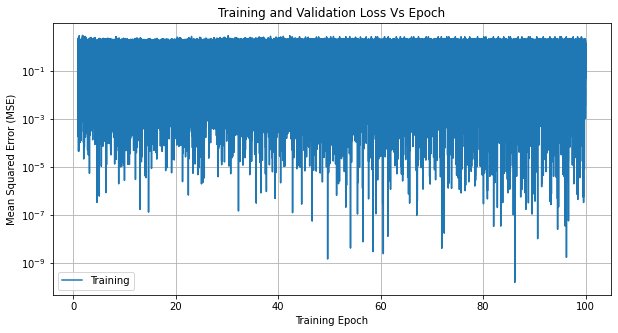

In [14]:
MLP2.train(n_epochs=100, verbose=50, plot=True)

In [15]:
MLP2.predict(stand=False, plot=False)

Best prediction: 312, Worst prediction: 128


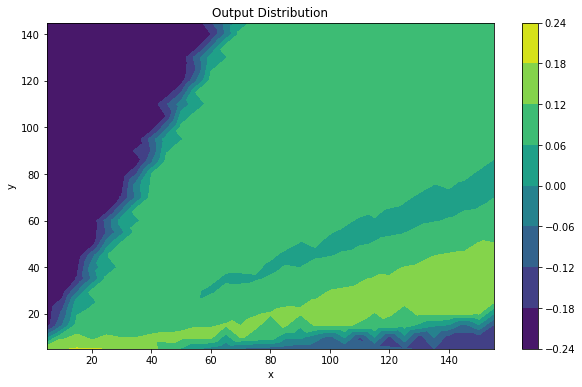

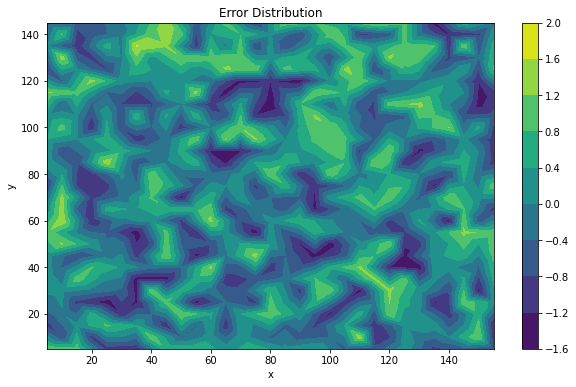

In [16]:
plot_Distribution(MLP2.data.train_in1, MLP2.test_outputs[:,0], truth=None, typ="contour")
plot_Distribution(MLP2.data.train_in1, MLP2.test_outputs[:,0], truth=MLP2.truth[:,0], typ="contour")

### Version 2
$[x_1, y_2, ..., x_n, y_n] \to [\delta x_i, ..., \delta x_n]$  
$[x_1, y_2, ..., x_n, y_n] \to [\delta y_i, ..., \delta y_n]$


In [17]:
DAT = DATA(path=1, load=True, LAT="FCC", dis="disNodes", dN=20, model="MLP", format=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [18]:
in_size = DAT.train_in2.shape[-1]
out_size = DAT.dx_out2.shape[-1]
h_size = []

BATCH_SIZE = 1
LEARNING_RATE = 1e-3

In [19]:
trainDSx = Dataset_(DAT.train_in2, DAT.dx_out2[0])
trainDSy = Dataset_(DAT.train_in2, DAT.dy_out2[0])

trainx_dataloader = DataLoader(dataset=trainDSx, batch_size=BATCH_SIZE, shuffle=True)
trainy_dataloader = DataLoader(dataset=trainDSy, batch_size=BATCH_SIZE, shuffle=True)

testx_dataloader = DataLoader(dataset=trainDSx, batch_size=BATCH_SIZE, shuffle=False)
testy_dataloader = DataLoader(dataset=trainDSy, batch_size=BATCH_SIZE, shuffle=False)

train_dataloader = trainx_dataloader
test_dataloader = testx_dataloader

In [20]:
MLP3 = MODEL(
    typ="MLP",
    model=MLP(in_size, h_size, out_size).to(device), 
    lossf=nn.MSELoss(),
    opt=("adam", 0),
    batch=BATCH_SIZE,
    lr=LEARNING_RATE,
    data=DAT,
    train_dataloader=test_dataloader, 
    val_dataloader=None, 
    test_dataloader=test_dataloader,
    scheduler=("min", 0.25, 16, 1e-4, True), 
    earlyStop=EarlyStopping(patience=500, min_delta=1e-4, verbose=True),
    w_init=weights_init,
)

summary(MLP3.model, input_size=(BATCH_SIZE, in_size))

Layer (type:depth-idx)                   Output Shape              Param #
MLP                                      [1, 450]                  --
├─Linear: 1-1                            [1, 450]                  405,450
Total params: 405,450
Trainable params: 405,450
Non-trainable params: 0
Total mult-adds (M): 0.41
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 1.62
Estimated Total Size (MB): 1.63

Epoch: 1 - Loss: 2955.549072265625
Epoch: 50 - Loss: 3.001843214035034
Epoch: 100 - Loss: 0.4992911219596863
Epoch: 150 - Loss: 0.023922791704535484
Epoch: 200 - Loss: 0.023845205083489418
Epoch: 250 - Loss: 9.807276364881545e-05
Epoch: 300 - Loss: 1.9259673535998445e-06
Epoch: 350 - Loss: 1.9214507762654875e-09
Epoch: 400 - Loss: 1.3057389613990722e-09
Epoch: 450 - Loss: 9.175924776949618e-12
Epoch: 500 - Loss: 5.617589293044345e-12
Epoch: 550 - Loss: 3.462497649708851e-12
Epoch: 600 - Loss: 2.624641389642468e-12
Epoch: 650 - Loss: 2.5386184040326887e-12
Epoch: 700 - Loss: 2.5258601633881828e-12
Epoch: 750 - Loss: 2.4200999277496082e-12
Early stopping triggered after 500 epochs without improvement.
Best Epoch: 778, with loss 2.243885416017277e-12


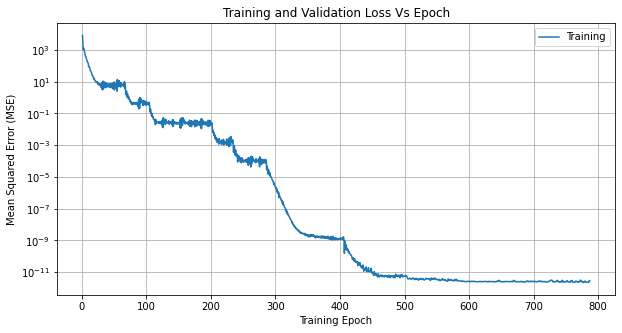

In [21]:
MLP3.train(n_epochs=1000, verbose=50, plot=True)

Best prediction: 0, Worst prediction: 0


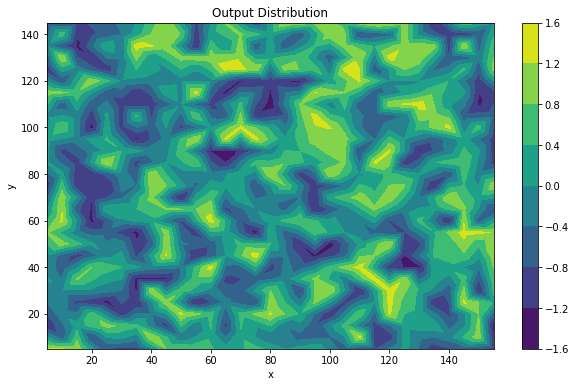

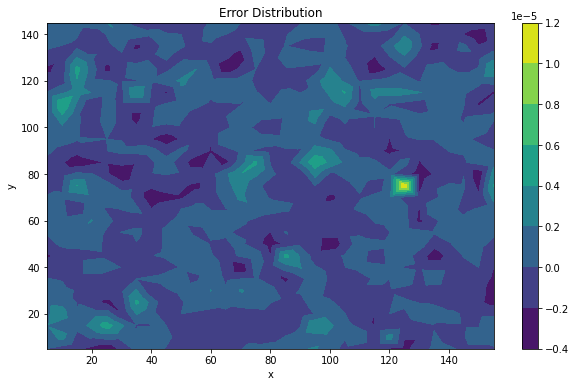

In [25]:
MLP3.predict(stand=False, plot=False)

plot_Distribution(MLP3.data.train_in1, MLP3.test_outputs[0], truth=None, typ="contour")
plot_Distribution(MLP3.data.train_in1, MLP3.test_outputs[0], truth=MLP3.truth[0], typ="contour")

In [24]:
for name, param in MLP3.model.state_dict().items():
    print(f"{name}: {param.shape}\n{param}\nTotal params: {param.numel()}\n")

fcOUT.weight: torch.Size([450, 900])
tensor([[-1.0224e-03, -3.2832e-03,  4.5770e-03,  ...,  7.1568e-03,
         -5.1185e-02,  7.4622e-02],
        [ 5.8908e-02,  6.0849e-02,  1.1379e-02,  ...,  1.4921e-02,
         -7.6899e-06,  3.8376e-02],
        [-5.7047e-02,  3.0647e-02,  3.4761e-02,  ...,  4.1097e-02,
          3.0172e-02, -4.1688e-02],
        ...,
        [-3.7530e-02, -1.7150e-02, -1.0250e-03,  ..., -1.9956e-02,
         -3.9086e-02, -3.8647e-02],
        [-2.7308e-02, -3.9133e-02,  1.4924e-02,  ...,  3.8355e-02,
         -1.8881e-03, -5.5246e-02],
        [ 3.6682e-02, -8.0171e-03,  3.4187e-02,  ..., -4.1472e-03,
         -7.7205e-03, -6.6228e-04]])
Total params: 405000

fcOUT.bias: torch.Size([450])
tensor([0.0090, 0.0120, 0.0075, 0.0082, 0.0103, 0.0080, 0.0109, 0.0104, 0.0094,
        0.0097, 0.0094, 0.0056, 0.0059, 0.0100, 0.0106, 0.0085, 0.0105, 0.0097,
        0.0087, 0.0096, 0.0094, 0.0095, 0.0086, 0.0089, 0.0090, 0.0103, 0.0073,
        0.0118, 0.0098, 0.0096, 0.0085,